# 04. Weather

What is the air actually doing on the day we model?

Everything so far has been geometry — where the sun sits, what gets in its way. None of it
knows whether the day is 18 °C and overcast or 40 °C and clear. Here one day of hourly
weather for the CBD lands in `data/weather_{date}.json`, and 06, 07 and 08 all read it.

In [12]:
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CONFIG = json.load(open("config.json"))

LAT, LON = CONFIG["lat"], CONFIG["lon"]
DATE = CONFIG["date"]

print(f"{LAT}, {LON}   {DATE}")

-37.8136, 144.9631   2026-01-27


## One day, from Open-Meteo

The archive endpoint serves hourly reanalysis for any past day. We only need the following 6 fields:

| field | who wants it |
|---|---|
| `temperature_2m` | the body (08), and the air the ground trades heat with (06) |
| `relative_humidity_2m` | the body (08) |
| `direct_radiation` | the beam — only reaches unshaded cells (06, 07) |
| `diffuse_radiation` | scattered sky light — reaches everything, scaled by SVF (06, 07) |
| `wind_speed_10m` | convection off the ground (06), and the body (08) |
| `cloud_cover` | context, mostly — it explains the other five |

In [13]:
import urllib.request

HOURLY = ["temperature_2m", "relative_humidity_2m", "direct_radiation",
          "diffuse_radiation", "wind_speed_10m", "cloud_cover"]

URL = ("https://archive-api.open-meteo.com/v1/archive"
       f"?latitude={LAT}&longitude={LON}&start_date={DATE}&end_date={DATE}"
       f"&hourly={','.join(HOURLY)}&timezone=Australia/Melbourne")

WX = f"data/weather_{DATE}.json"
os.makedirs("data", exist_ok=True)

if os.path.exists(WX):
    print(f"cached   {WX}")
else:
    urllib.request.urlretrieve(URL, WX)
    print(f"fetched  {WX}")

wx = json.load(open(WX))

fetched  data/weather_2026-01-27.json


In [14]:
# Reanalysis comes on a 9 km grid, so the request snaps to the nearest cell centre and the
# coordinates come back a few km off. One weather for the whole CBD.
print(f"asked for  {LAT}, {LON}")
print(f"got        {wx['latitude']:.4f}, {wx['longitude']:.4f}   {wx['elevation']:.0f} m   {wx['timezone_abbreviation']}\n")

for k, u in wx["hourly_units"].items():
    print(f"  {k:22s} {u}")

print("\n13:00 as it arrived:")
for k, v in wx["hourly"].items():
    print(f"  {k:22s} {v[13]}")

asked for  -37.8136, 144.9631
got        -37.7856, 144.9398   19 m   GMT+10

  time                   iso8601
  temperature_2m         °C
  relative_humidity_2m   %
  direct_radiation       W/m²
  diffuse_radiation      W/m²
  wind_speed_10m         km/h
  cloud_cover            %

13:00 as it arrived:
  time                   2026-01-27T13:00
  temperature_2m         40.8
  relative_humidity_2m   16
  direct_radiation       896.0
  diffuse_radiation      113.0
  wind_speed_10m         18.0
  cloud_cover            0


**The units trap**

OpenMeteo returns wind in **km/h** our formulas want **m/s** so save the value in **m/s** (divide by 3.6) and throwaway the **km/h**.

In [15]:
w = pd.DataFrame(wx["hourly"])
w.index = pd.to_datetime(w.pop("time")).dt.hour
w.index.name = "hour"

w["wind_ms"] = w["wind_speed_10m"] / 3.6      # km/h -> m/s, the only conversion in here

In [16]:
HOURS = range(6, 21)                          # 06:00 to 20:00, the hours 01 marched the sun through

tbl = w.loc[HOURS, ["temperature_2m", "relative_humidity_2m", "direct_radiation",
                    "diffuse_radiation", "wind_ms", "cloud_cover"]]
tbl.columns = ["T (C)", "RH (%)", "direct (W/m2)", "diffuse (W/m2)", "wind (m/s)", "cloud (%)"]
print(tbl.round(1).to_string())

      T (C)  RH (%)  direct (W/m2)  diffuse (W/m2)  wind (m/s)  cloud (%)
hour                                                                     
6      15.7      85            4.0             6.0         0.8          0
7      17.6      73           91.0            49.0         1.0          0
8      21.3      56          270.0            77.0         1.8          0
9      27.8      38          465.0            92.0         2.0          0
10     33.2      28          643.0           102.0         3.8          0
11     36.8      22          780.0           108.0         4.9          1
12     39.0      18          867.0           111.0         5.3          2
13     40.8      16          896.0           113.0         5.0          0
14     42.4      14          868.0           111.0         4.4          0
15     43.3      13          780.0           107.0         3.9          5
16     43.4      12          608.0           121.0         3.6         28
17     43.4      12          428.0    

## The day, six ways

One row each, sharing a clock. Grey is the hours outside 06–20, which nothing downstream
models.

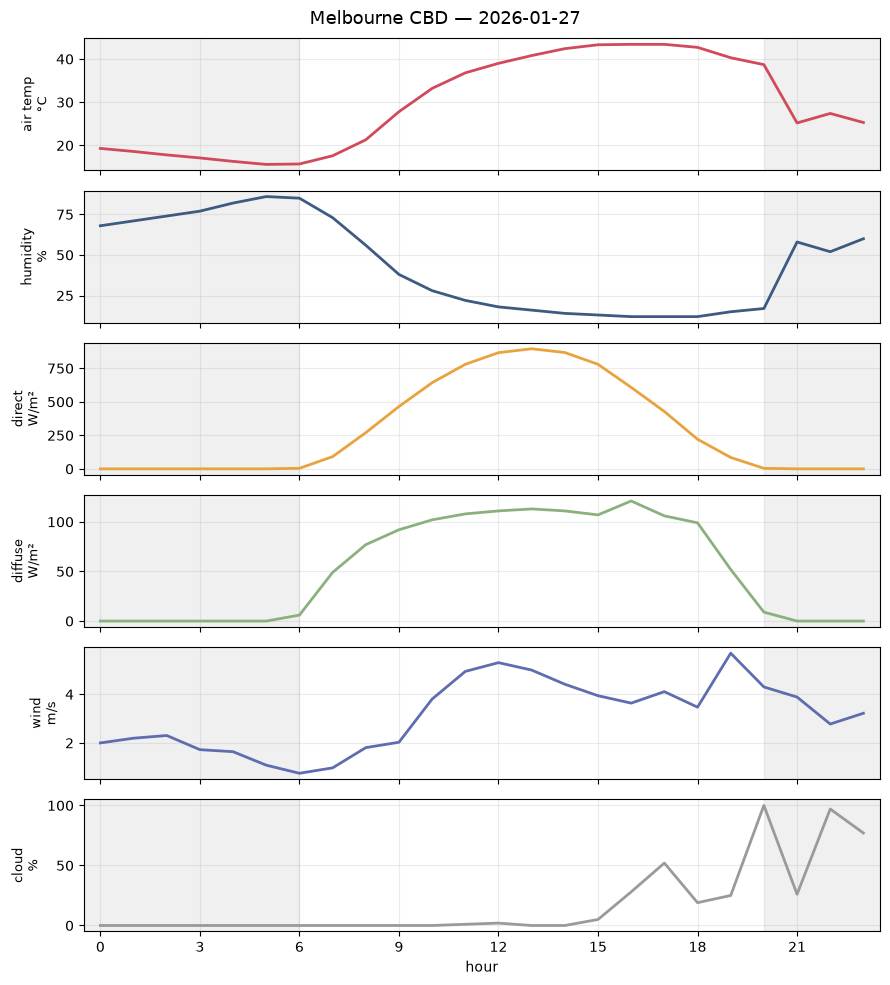

In [17]:
PANELS = [("temperature_2m",      "air temp\n°C",   "#d1495b"),
          ("relative_humidity_2m", "humidity\n%",    "#3d5a80"),
          ("direct_radiation",     "direct\nW/m²",   "#e8a33d"),
          ("diffuse_radiation",    "diffuse\nW/m²",  "#8ab17d"),
          ("wind_ms",              "wind\nm/s",      "#5f6caf"),
          ("cloud_cover",          "cloud\n%",       "#9a9a9a")]

fig, axes = plt.subplots(6, 1, figsize=(9, 10), sharex=True)

for ax, (col, label, colour) in zip(axes, PANELS):
    ax.plot(w.index, w[col], color=colour, lw=2)
    ax.axvspan(-0.5, 6, color="k", alpha=0.06)      # before 06:00
    ax.axvspan(20, 23.5, color="k", alpha=0.06)     # after 20:00
    ax.set_ylabel(label, fontsize=9)
    ax.grid(alpha=0.25)

axes[-1].set_xlim(-0.5, 23.5)
axes[-1].set_xticks(range(0, 24, 3))
axes[-1].set_xlabel("hour")
fig.suptitle(f"Melbourne CBD — {DATE}", fontsize=13)
fig.tight_layout()

## Direct is the part shade can take

Sunlight arrives two ways. The **direct** beam comes straight off the disc, so a wall or a
crown takes all of it — that is the map 01 and 02 built. **Diffuse** light comes off the
whole sky, and a shaded cell still gets whatever share of sky it can see, which is what 03
measured.

So shade is only ever worth as much as the direct share of the total. And because diffuse
never falls to zero while the sun is up, standing under a tree never gets you to zero
either.

In [18]:
total = w["direct_radiation"] + w["diffuse_radiation"]
share = (w["direct_radiation"] / total.replace(0, np.nan)).fillna(0)

peak = total.idxmax()
print(f"peak sun    {peak:02d}:00   {total[peak]:.0f} W/m2 total, {share[peak] * 100:.0f}% direct")
print(f"cloudiest   {w['cloud_cover'].idxmax():02d}:00   cloud {w['cloud_cover'].max():.0f}%")
print(f"\nover 06-20, direct is {share.loc[HOURS].mean() * 100:.0f}% of what arrives on average")

peak sun    13:00   1009 W/m2 total, 89% direct
cloudiest   20:00   cloud 100%

over 06-20, direct is 75% of what arrives on average


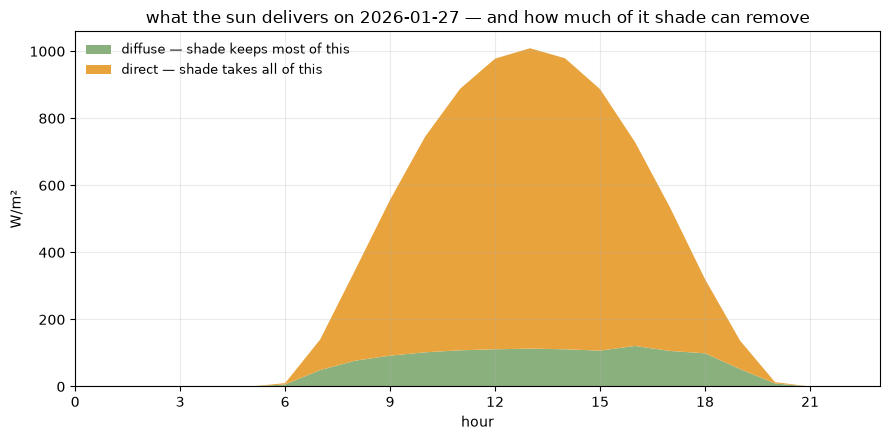

In [19]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.stackplot(w.index, w["diffuse_radiation"], w["direct_radiation"],
             labels=["diffuse — shade keeps most of this", "direct — shade takes all of this"],
             colors=["#8ab17d", "#e8a33d"])
ax.set_xlim(0, 23); ax.set_xticks(range(0, 24, 3))
ax.set_xlabel("hour"); ax.set_ylabel("W/m²")
ax.legend(loc="upper left", fontsize=9, frameon=False)
ax.grid(alpha=0.25)
ax.set_title(f"what the sun delivers on {DATE} — and how much of it shade can remove")
fig.tight_layout()